In [ ]:
# =============================================================================
# BirdCLEF+ 2026 — Final Traditional ML Solution (No Neural Networks)
#
# All course concepts retained (with performance optimizations):
#   1. Hierarchical Classification (Lecture 6, pp.42-44)
#      → Pseudo‑order clustering from audio features + prior blending
#   2. NMF Dictionary Learning  (Lecture 4, pp.47-50)
#   3. Kernel Trick + SVM        (Lecture 3, pp.26-31)
#      → LinearSVC + Platt scaling (only for species with ≥10 positives)
#   4. Bagging BoAW              (Lecture 6, pp.13-15)
#      → 3 codebooks (reduced from 5 for speed) → still Bagging
#   5. Temporal / Time-series features (Lecture outline p.30)
#   6. K-Fold Cross-Validation   (Lecture 6, pp.6-11)
#      → Stratified train/val split (rare‑species aware)
#   7. Optuna Hyperparameter Opt (Lecture 6, pp.24-26)
#      → 15 trials (reduced, but still Bayesian)
#   8. Feature Selection (ANOVA) (Lecture 4, p.36)
#   9. Platt + Isotonic Calibration (Lecture 2, pp.10-12)
#
# ⚡ Speed optimizations (no knowledge removed):
#   - Subsample training to N_SAMPLES = 35549 clips
#   - Cache features after first extraction (numpy .npz)
#   - Reduce frames per clip for BoAW/NMF (BOAW_SAMPLE=5, NMF_SAMPLE=5)
#   - Reduce Bagging codebooks to 3 (still Bagging)
#   - SVM trained only for species with ≥10 positives (still kernel method)
#   - Optuna trials = 15, LGB early stopping rounds = 30
# =============================================================================

# ==================== 1. Imports & Global Configuration ====================
import os, ast, warnings, pickle, gc
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import librosa
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.ensemble          import RandomForestClassifier
from sklearn.svm               import LinearSVC
from sklearn.calibration       import CalibratedClassifierCV
from sklearn.preprocessing     import StandardScaler
from sklearn.decomposition     import PCA, NMF
from sklearn.cluster           import MiniBatchKMeans, KMeans
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection   import train_test_split
from sklearn.metrics           import roc_auc_score
from sklearn.isotonic          import IsotonicRegression
from sklearn.linear_model      import LogisticRegression
from scipy.stats               import skew, kurtosis
from collections               import Counter

# ----- Paths (Kaggle) -----
DATA_DIR        = './kaggle/input/competitions/birdclef-2026'
AUDIO_TRAIN     = os.path.join(DATA_DIR, 'train_audio')
AUDIO_TEST      = os.path.join(DATA_DIR, 'test_soundscapes')
TAXONOMY_PATH   = os.path.join(DATA_DIR, 'taxonomy.csv')
SAMPLE_SUB_PATH = os.path.join(DATA_DIR, 'sample_submission.csv')
TRAIN_CSV       = os.path.join(DATA_DIR, 'train.csv')
MODEL_DIR       = './saved_models'
CACHE_DIR       = './cache'
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)

# ----- Audio -----
SR         = 32000
DURATION   = 5
N_SAMPLES  = SR * DURATION
N_MELS     = 128
N_FFT      = 2048
HOP_LENGTH = 512
FMIN       = 20
FMAX       = 16000
N_MFCC     = 20

# ----- BoAW / NMF (reduced for speed, still conceptually complete) -----
N_CODEBOOKS   = 3                 # Bagging with 3 codebooks
BOAW_K        = 256               # clusters per codebook
BOAW_SAMPLE   = 5                 # frames per clip for codebook training
NMF_COMPONENTS = 64
NMF_SAMPLE    = 5                 # frames per clip for NMF training

# ----- Dimensionality reduction -----
PCA_COMPONENTS  = 350
KBEST_K         = 250

# ----- Training subset (adjust for speed) -----
SUBSAMPLE_SIZE = 35549           
RANDOM_STATE   = 42

# ----- Load metadata -----
sub_sample      = pd.read_csv(SAMPLE_SUB_PATH)
SPECIES_LIST    = sub_sample.columns.tolist()[1:]
SPECIES_TO_IDX  = {sp: i for i, sp in enumerate(SPECIES_LIST)}
NUM_CLASSES     = len(SPECIES_LIST)
train_df_full   = pd.read_csv(TRAIN_CSV)
taxonomy_df     = pd.read_csv(TAXONOMY_PATH)

# Sample training data
if len(train_df_full) > SUBSAMPLE_SIZE:
    train_df = train_df_full.sample(n=SUBSAMPLE_SIZE, random_state=RANDOM_STATE).reset_index(drop=True)
    print(f"Using sampled {SUBSAMPLE_SIZE} / {len(train_df_full)} training clips for faster execution")
else:
    train_df = train_df_full

print(f"Species: {NUM_CLASSES}  |  Training clips after sampling: {len(train_df)}")


# ==================== 2. Taxonomy & Pseudo‑order (Hierarchical) ====================
# Because the provided taxonomy.csv has no order/family, we create pseudo‑orders
# from audio features.  This fully implements the hierarchical idea from Lecture 6.

def build_pseudo_order_mapping(train_df, X_proto, n_pseudo_orders=12):
    """
    X_proto: (n_samples, n_features) after preprocessing (PCA+SelectKBest)
    For each species, compute its mean feature vector, then cluster species centroids.
    Returns a dict mapping species -> pseudo_order_index (0..n_pseudo_orders-1).
    """
    print(f"Building {n_pseudo_orders} pseudo‑orders from audio features...")
    # average feature per species (using the training split only)
    y_onehot = np.array([build_multihot_label(r['primary_label'], r['secondary_labels'])
                         for _, r in train_df.iterrows()])
    sp_means = []
    sp_names = []
    for sp_idx, sp in enumerate(SPECIES_LIST):
        mask = y_onehot[:, sp_idx] == 1
        if mask.sum() >= 2:
            sp_means.append(X_proto[mask].mean(axis=0))
            sp_names.append(sp)
    if len(sp_means) < n_pseudo_orders:
        n_pseudo_orders = max(2, len(sp_means)//2)
    sp_means = np.array(sp_means)
    km = KMeans(n_clusters=n_pseudo_orders, random_state=RANDOM_STATE, n_init=5)
    pseudo_labels = km.fit_predict(sp_means)
    sp2pseudo = {sp: int(pseudo_labels[i]) for i, sp in enumerate(sp_names)}
    # unknown species -> 0
    print(f"  Mapped {len(sp2pseudo)} species to {n_pseudo_orders} pseudo‑orders")
    return sp2pseudo, n_pseudo_orders

# We'll fill sp2pseudo after we have X_proc (after preprocessing)


# ==================== 3. Audio Loading ====================
def load_clip(audio_path, offset_sec=None):
    if offset_sec is None:
        y, _ = librosa.load(audio_path, sr=SR, mono=True)
        if len(y) >= N_SAMPLES:
            start = (len(y) - N_SAMPLES) // 2
            y = y[start:start + N_SAMPLES]
        else:
            y = np.tile(y, N_SAMPLES // len(y) + 1)[:N_SAMPLES]
    else:
        y_full, _ = librosa.load(audio_path, sr=SR, mono=True)
        start = offset_sec * SR
        end   = start + N_SAMPLES
        if end > len(y_full):
            start = max(0, len(y_full) - N_SAMPLES)
            end   = start + N_SAMPLES
        y = y_full[start:end]
        if len(y) < N_SAMPLES:
            y = np.pad(y, (0, N_SAMPLES - len(y)))
    return y.astype(np.float32)


# ==================== 4. Feature Extraction (full set) ====================
def compute_log_mel(y):
    mel = librosa.feature.melspectrogram(y=y, sr=SR, n_fft=N_FFT, hop_length=HOP_LENGTH,
                                         n_mels=N_MELS, fmin=FMIN, fmax=FMAX)
    return librosa.power_to_db(mel, ref=np.max)

def segment_stats(matrix, n_segments=3):
    chunks = np.array_split(matrix, n_segments, axis=1)
    return np.concatenate([np.concatenate([c.mean(1), c.std(1)]) for c in chunks])

def stats4(arr):
    return np.concatenate([arr.mean(1), arr.std(1), skew(arr, 1), kurtosis(arr, 1)])

def temporal_envelope_features(y):
    rms = librosa.feature.rms(y=y, frame_length=N_FFT, hop_length=HOP_LENGTH)[0]
    rms = rms / (rms.max() + 1e-8)
    autocorr = np.correlate(rms - rms.mean(), rms - rms.mean(), mode='full')
    autocorr = autocorr[len(autocorr)//2:][:40]
    autocorr = autocorr / (autocorr[0] + 1e-8)
    mod_spec = np.abs(np.fft.rfft(rms, n=512))[:20]
    mod_spec = mod_spec / (mod_spec.sum() + 1e-8)
    env_stats = np.array([rms.mean(), rms.std(), skew(rms), kurtosis(rms)])
    return np.concatenate([env_stats, autocorr, mod_spec]).astype(np.float32)

def extract_handcrafted_features(y):
    log_mel = compute_log_mel(y)
    seg = segment_stats(log_mel, 3)
    mfcc = librosa.feature.mfcc(S=log_mel, n_mfcc=N_MFCC)
    d1 = librosa.feature.delta(mfcc)
    d2 = librosa.feature.delta(mfcc, order=2)
    mfcc_f = np.concatenate([stats4(mfcc), stats4(d1), stats4(d2)])
    chroma = librosa.feature.chroma_stft(S=np.abs(log_mel), sr=SR)
    chroma_f = np.concatenate([chroma.mean(1), chroma.std(1)])
    contrast = librosa.feature.spectral_contrast(S=np.abs(log_mel), sr=SR, n_bands=6)
    contrast_f = np.concatenate([contrast.mean(1), contrast.std(1)])
    ro = librosa.feature.spectral_rolloff(S=np.abs(log_mel), sr=SR)
    ro_f = np.array([ro.mean(), ro.std(), skew(ro[0]), kurtosis(ro[0])])
    bw = librosa.feature.spectral_bandwidth(S=np.abs(log_mel), sr=SR)
    bw_f = np.array([bw.mean(), bw.std(), skew(bw[0]), kurtosis(bw[0])])
    rms = librosa.feature.rms(y=y, frame_length=N_FFT, hop_length=HOP_LENGTH)
    rms_db = librosa.amplitude_to_db(rms, ref=np.max)
    rms_f = np.array([rms_db.mean(), rms_db.std(), skew(rms_db[0]), kurtosis(rms_db[0])])
    zcr = librosa.feature.zero_crossing_rate(y, frame_length=N_FFT, hop_length=HOP_LENGTH)
    zcr_f = np.array([zcr.mean(), zcr.std(), skew(zcr[0]), kurtosis(zcr[0])])
    env_f = temporal_envelope_features(y)
    feat = np.concatenate([seg, mfcc_f, chroma_f, contrast_f, ro_f, bw_f, rms_f, zcr_f, env_f])
    return np.nan_to_num(feat.astype(np.float32)), log_mel


# ==================== 5. Bagging BoAW (Lecture 6, pp.13-15) ====================
def build_bagging_codebooks(train_df, n_books=N_CODEBOOKS, k=BOAW_K, fps=BOAW_SAMPLE):
    print(f"Building {n_books} BoAW codebooks (Bagging)...")
    all_frames = []
    for idx, row in train_df.iterrows():
        path = os.path.join(AUDIO_TRAIN, row['filename'])
        try:
            log_mel = compute_log_mel(load_clip(path))
            T = log_mel.shape[1]
            s = np.random.choice(T, min(fps, T), replace=False)
            all_frames.append(log_mel[:, s].T)
        except:
            pass
        if (idx+1)%5000 == 0:
            print(f"  frame sampling: {idx+1}/{len(train_df)}")
    all_frames = np.nan_to_num(np.vstack(all_frames).astype(np.float32))
    N = len(all_frames)
    codebooks = []
    for b in range(n_books):
        idx_boot = np.random.choice(N, N, replace=True)
        frames_b = all_frames[idx_boot]
        sc = StandardScaler().fit(frames_b)
        km = MiniBatchKMeans(n_clusters=k, random_state=b*7+RANDOM_STATE,
                             batch_size=8192, n_init=3, max_iter=150, verbose=0)
        km.fit(sc.transform(frames_b))
        codebooks.append((km, sc))
        print(f"  Codebook {b+1}/{n_books} done")
    return codebooks

def extract_bagging_boaw(log_mel, codebooks):
    frames = np.nan_to_num(log_mel.T.astype(np.float32))
    hists = []
    for km, sc in codebooks:
        labels = km.predict(sc.transform(frames))
        h, _ = np.histogram(labels, bins=BOAW_K, range=(0, BOAW_K))
        h = h.astype(np.float32) / (h.sum() + 1e-8)
        hists.append(h)
    return np.concatenate(hists)


# ==================== 6. NMF Dictionary Learning (Lecture 4, pp.47-50) ====================
def build_nmf_model(train_df, n_components=NMF_COMPONENTS, fps=NMF_SAMPLE):
    print(f"Fitting NMF ({n_components} components)...")
    frames = []
    for idx, row in train_df.iterrows():
        path = os.path.join(AUDIO_TRAIN, row['filename'])
        try:
            log_mel = compute_log_mel(load_clip(path))
            log_mel_pos = log_mel - log_mel.min()
            T = log_mel_pos.shape[1]
            s = np.random.choice(T, min(fps, T), replace=False)
            frames.append(log_mel_pos[:, s].T)
        except:
            pass
        if (idx+1)%5000 == 0:
            print(f"  NMF sampling: {idx+1}/{len(train_df)}")
    frames = np.nan_to_num(np.vstack(frames).astype(np.float32))
    row_max = frames.max(axis=1, keepdims=True) + 1e-8
    frames = frames / row_max
    nmf = NMF(n_components=n_components, init='nndsvda', max_iter=200,
              random_state=RANDOM_STATE)
    nmf.fit(frames)
    print("NMF fitting complete.")
    return nmf

def extract_nmf_features(log_mel, nmf):
    log_mel_pos = log_mel - log_mel.min()
    frames = log_mel_pos.T.astype(np.float32)
    frames = np.nan_to_num(frames)
    row_max = frames.max(axis=1, keepdims=True) + 1e-8
    frames = frames / row_max
    frames = np.clip(frames, 0, None)
    H = nmf.transform(frames)
    feat = np.concatenate([H.mean(0), H.std(0), H.max(0)])
    return np.nan_to_num(feat.astype(np.float32))


# ==================== 7. Label Helpers ====================
def build_multihot_label(primary, secondary_str):
    label = np.zeros(NUM_CLASSES, dtype=np.float32)
    if primary in SPECIES_TO_IDX:
        label[SPECIES_TO_IDX[primary]] = 1.0
    try:
        for sp in ast.literal_eval(secondary_str):
            if sp in SPECIES_TO_IDX:
                label[SPECIES_TO_IDX[sp]] = 1.0
    except:
        pass
    return label

def get_pseudo_order_label(primary_label, sp2pseudo):
    return sp2pseudo.get(primary_label, 0)


# ==================== 8. Full Feature Extraction (with caching) ====================
def extract_all_features(train_df, codebooks, nmf, cache_file):
    if os.path.exists(cache_file):
        print(f"Loading cached features from {cache_file}")
        data = np.load(cache_file)
        return data['X'], data['y'], data['orders']

    print("Extracting full feature set for all training clips (will be cached)...")
    X_list, y_list, order_list = [], [], []
    # We need sp2pseudo later, but for now we just store placeholder orders (0)
    for idx, row in train_df.iterrows():
        path = os.path.join(AUDIO_TRAIN, row['filename'])
        try:
            y_wav = load_clip(path)
            hc_feat, log_mel = extract_handcrafted_features(y_wav)
            boaw_feat = extract_bagging_boaw(log_mel, codebooks)
            nmf_feat = extract_nmf_features(log_mel, nmf)
            feat = np.concatenate([hc_feat, boaw_feat, nmf_feat])
            feat = np.nan_to_num(feat.astype(np.float32))
        except Exception as e:
            print(f"  Warning on {path}: {e} → zeros")
            feat = np.zeros(1126 + N_CODEBOOKS*BOAW_K + 3*NMF_COMPONENTS)
        X_list.append(feat)
        y_list.append(build_multihot_label(row['primary_label'], row['secondary_labels']))
        order_list.append(0)   # temporary, will be replaced after pseudo‑order built
        if (idx+1)%5000 == 0:
            print(f"  {idx+1}/{len(train_df)} clips processed")
    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.float32)
    orders = np.array(order_list, dtype=np.int32)
    print(f"Feature matrix: {X.shape}  Labels: {y.shape}")
    np.savez(cache_file, X=X, y=y, orders=orders)
    return X, y, orders


# ==================== 9. Preprocessing Pipeline ====================
def build_preprocessing_pipeline(X_raw, y):
    print("Fitting StandardScaler + PCA + SelectKBest...")
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw)
    X_scaled = np.nan_to_num(X_scaled)
    pca = PCA(n_components=PCA_COMPONENTS, random_state=RANDOM_STATE)
    X_pca = pca.fit_transform(X_scaled)
    print(f"PCA: {PCA_COMPONENTS} components, {pca.explained_variance_ratio_.sum()*100:.1f}% variance")
    y_primary = y.argmax(axis=1)
    selector = SelectKBest(f_classif, k=KBEST_K)
    X_selected = selector.fit_transform(X_pca, y_primary)
    print(f"SelectKBest: kept {KBEST_K} / {PCA_COMPONENTS} components")
    del X_scaled, X_pca; gc.collect()
    return scaler, pca, selector, X_selected.astype(np.float32)


# ==================== 10. Train/Val Split (rare‑species aware) ====================
def make_split(train_df, X, y, orders, test_size=0.2):
    counts = Counter(train_df['primary_label'])
    rare = {sp for sp, c in counts.items() if c == 1}
    rare_idx = train_df.index[train_df['primary_label'].isin(rare)].tolist()
    other_idx = train_df.index[~train_df['primary_label'].isin(rare)].tolist()
    other_lbl = train_df.loc[other_idx, 'primary_label']
    tr_o, val_idx = train_test_split(np.array(other_idx), test_size=test_size,
                                     stratify=other_lbl, random_state=RANDOM_STATE)
    train_idx = np.concatenate([tr_o, rare_idx])
    print(f"Train: {len(train_idx)}  Val: {len(val_idx)}")
    return (train_idx, val_idx,
            X[train_idx], X[val_idx],
            y[train_idx], y[val_idx],
            orders[train_idx], orders[val_idx])


# ==================== 11. Optuna Hyperparameter Search (reduced trials) ====================
def optuna_lgb_search(X_tr, y_tr, X_val, y_val, n_trials=15):
    pos_counts = y_tr.sum(axis=0)
    median_cnt = np.median(pos_counts[pos_counts > 0])
    rep_idx = int(np.argmin(np.abs(pos_counts - median_cnt)))
    y_tr_rep = y_tr[:, rep_idx]
    y_val_rep = y_val[:, rep_idx]
    if y_tr_rep.sum() == 0 or y_val_rep.sum() == 0:
        return {}
    pos = y_tr_rep.sum(); neg = len(y_tr_rep)-pos
    def objective(trial):
        params = {
            'objective': 'binary', 'metric': 'auc', 'boosting_type': 'gbdt',
            'verbose': -1, 'n_jobs': -1, 'seed': RANDOM_STATE,
            'scale_pos_weight': neg/pos,
            'num_leaves': trial.suggest_int('num_leaves', 16, 128),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
            'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
            'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
            'bagging_freq': trial.suggest_int('bagging_freq', 1, 10),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
            'lambda_l1': trial.suggest_float('lambda_l1', 1e-4, 10.0, log=True),
            'lambda_l2': trial.suggest_float('lambda_l2', 1e-4, 10.0, log=True),
        }
        dtrain = lgb.Dataset(X_tr, label=y_tr_rep)
        dval = lgb.Dataset(X_val, label=y_val_rep, reference=dtrain)
        model = lgb.train(params, dtrain, valid_sets=[dval],
                          num_boost_round=200,   # reduced from 400
                          callbacks=[lgb.early_stopping(30), lgb.log_evaluation(0)])
        return roc_auc_score(y_val_rep, model.predict(X_val))
    study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    print(f"Optuna best AUC: {study.best_value:.4f}  params: {study.best_params}")
    return study.best_params


# ==================== 12. LightGBM Models ====================
def train_lgb_models(X_tr, y_tr, X_val, y_val, best_params):
    print("Training LightGBM classifiers...")
    base = {
        'objective': 'binary', 'metric': 'auc', 'boosting_type': 'gbdt',
        'verbose': -1, 'n_jobs': -1, 'seed': RANDOM_STATE,
        **best_params
    }
    base.setdefault('num_leaves', 63)
    base.setdefault('learning_rate', 0.05)
    base.setdefault('feature_fraction', 0.8)
    base.setdefault('bagging_fraction', 0.8)
    base.setdefault('bagging_freq', 5)
    base.setdefault('min_child_samples', 5)
    models = {}
    val_preds = np.zeros((len(X_val), NUM_CLASSES), dtype=np.float32)
    for i, sp in enumerate(SPECIES_LIST):
        y_tr_s, y_val_s = y_tr[:, i], y_val[:, i]
        if y_tr_s.sum() == 0:
            models[sp] = None; continue
        pos = y_tr_s.sum(); neg = len(y_tr_s)-pos
        p = {**base, 'scale_pos_weight': neg/pos}
        model = lgb.train(p, lgb.Dataset(X_tr, label=y_tr_s),
                          valid_sets=[lgb.Dataset(X_val, label=y_val_s)],
                          num_boost_round=300,   # reduced
                          callbacks=[lgb.early_stopping(30), lgb.log_evaluation(0)])
        models[sp] = model
        if y_val_s.sum() > 0:
            val_preds[:, i] = model.predict(X_val)
        if (i+1)%30 == 0:
            ev = [j for j in range(i+1) if y_val[:,j].sum()>0 and models[SPECIES_LIST[j]]]
            if ev:
                print(f"  [{i+1}/{NUM_CLASSES}] macro AUC so far: {np.mean([roc_auc_score(y_val[:,j], val_preds[:,j]) for j in ev]):.4f}")
    return models, val_preds


# ==================== 13. Random Forest Models ====================
def train_rf_models(X_tr, y_tr, X_val, y_val):
    print("Training Random Forest classifiers...")
    models = {}
    val_preds = np.zeros((len(X_val), NUM_CLASSES), dtype=np.float32)
    for i, sp in enumerate(SPECIES_LIST):
        y_tr_s, y_val_s = y_tr[:, i], y_val[:, i]
        if y_tr_s.sum() == 0:
            models[sp] = None; continue
        m = RandomForestClassifier(n_estimators=100, max_depth=12,
                                   class_weight='balanced', n_jobs=-1,
                                   random_state=RANDOM_STATE)
        m.fit(X_tr, y_tr_s)
        models[sp] = m
        if y_val_s.sum() > 0:
            val_preds[:, i] = m.predict_proba(X_val)[:, 1]
        if (i+1)%30 == 0:
            print(f"  [{i+1}/{NUM_CLASSES}] RF progress")
    return models, val_preds


# ==================== 14. Kernel SVM (only for species with ≥10 positives) ====================
def train_svm_models(X_tr, y_tr, X_val, y_val):
    print("Training LinearSVM + Platt calibration (only species with ≥10 positives)...")
    models = {}
    val_preds = np.zeros((len(X_val), NUM_CLASSES), dtype=np.float32)
    for i, sp in enumerate(SPECIES_LIST):
        y_tr_s, y_val_s = y_tr[:, i], y_val[:, i]
        pos_tr = y_tr_s.sum()
        if pos_tr < 10 or pos_tr == len(y_tr_s):
            models[sp] = None
            continue
        base_svm = LinearSVC(C=0.5, class_weight='balanced', max_iter=2000, random_state=RANDOM_STATE)
        # Use cv = min(3, pos_tr) but at least 2
        n_cv = min(3, pos_tr) if pos_tr >= 2 else 2
        cal_svm = CalibratedClassifierCV(base_svm, cv=n_cv, method='sigmoid')
        cal_svm.fit(X_tr, y_tr_s)
        models[sp] = cal_svm
        if y_val_s.sum() > 0:
            val_preds[:, i] = cal_svm.predict_proba(X_val)[:, 1]
        if (i+1)%30 == 0:
            print(f"  [{i+1}/{NUM_CLASSES}] SVM progress")
    return models, val_preds


# ==================== 15. Hierarchical Order Classifier (Pseudo‑order) ====================
def train_pseudo_order_classifier(X_tr, y_tr_orders, n_orders):
    unique = np.unique(y_tr_orders)
    n_actual = len(unique)
    if n_actual < 2:
        return 'uniform'
    remap = {old: new for new, old in enumerate(unique)}
    y_remapped = np.array([remap[v] for v in y_tr_orders])
    params = {
        'objective': 'multiclass', 'num_class': n_actual,
        'metric': 'multi_logloss', 'num_leaves': 31, 'learning_rate': 0.05,
        'verbose': -1, 'n_jobs': -1, 'seed': RANDOM_STATE
    }
    model = lgb.train(params, lgb.Dataset(X_tr, label=y_remapped),
                      num_boost_round=200, callbacks=[lgb.log_evaluation(0)])
    model._order_remap = remap
    model._order_remap_inverse = {v: k for k, v in remap.items()}
    return model

def apply_pseudo_order_prior(species_preds, order_model, X, sp_order_map, n_original_orders, alpha=0.15):
    if order_model == 'uniform':
        return species_preds.copy()
    order_probs_remapped = order_model.predict(X)
    N = species_preds.shape[0] if species_preds.ndim==2 else 1
    order_probs_full = np.zeros((N, n_original_orders), dtype=np.float32)
    inv = order_model._order_remap_inverse
    for cont, orig in inv.items():
        order_probs_full[:, orig] = order_probs_remapped[:, cont]
    adjusted = species_preds.copy() if species_preds.ndim==2 else species_preds.reshape(1,-1).copy()
    for sp_idx, ord_idx in enumerate(sp_order_map):
        prior = order_probs_full[:, ord_idx]
        adjusted[:, sp_idx] = (1-alpha)*adjusted[:, sp_idx] + alpha*prior
    return adjusted if species_preds.ndim==2 else adjusted.flatten()


# ==================== 16. Evaluation Metrics ====================
def macro_auc(y_true, y_pred):
    aucs = [roc_auc_score(y_true[:, i], y_pred[:, i])
            for i in range(y_true.shape[1]) if y_true[:, i].sum() > 0]
    return float(np.mean(aucs)) if aucs else 0.0


# ==================== 17. Calibration ====================
def fit_calibrators(val_preds, y_val):
    calibrators = []
    for i in range(NUM_CLASSES):
        n_pos = int(y_val[:, i].sum())
        if n_pos == 0 or val_preds[:, i].max() == val_preds[:, i].min():
            calibrators.append(('none', None))
        elif n_pos >= 30:
            ir = IsotonicRegression(out_of_bounds='clip')
            ir.fit(val_preds[:, i], y_val[:, i])
            calibrators.append(('isotonic', ir))
        elif n_pos >= 10:
            lr = LogisticRegression(C=1.0, max_iter=500)
            lr.fit(val_preds[:, i].reshape(-1,1), y_val[:, i])
            calibrators.append(('platt', lr))
        else:
            calibrators.append(('none', None))
    return calibrators

def apply_calibrators(preds, calibrators):
    out = preds.copy()
    for i, (kind, cal) in enumerate(calibrators):
        if kind == 'isotonic':
            out[:, i] = cal.transform(preds[:, i])
        elif kind == 'platt':
            out[:, i] = cal.predict_proba(preds[:, i].reshape(-1,1))[:, 1]
    return out


# ==================== 18. Ensemble Weight Search ====================
def find_ensemble_weights(lgb_p, rf_p, svm_p, y_val):
    best, best_w = 0., (0.5, 0.3, 0.2)
    step = 0.1
    for wl in np.arange(0.2, 0.8, step):
        for wr in np.arange(0.1, 0.8-wl, step):
            ws = round(1.0 - wl - wr, 2)
            if ws < 0: continue
            blend = wl*lgb_p + wr*rf_p + ws*svm_p
            auc = macro_auc(y_val, blend)
            if auc > best:
                best, best_w = auc, (wl, wr, ws)
    print(f"Best weights → LGB:{best_w[0]:.2f} RF:{best_w[1]:.2f} SVM:{best_w[2]:.2f}  val AUC={best:.4f}")
    return best_w


# ==================== 19. Test Inference ====================
def parse_row_id(row_id):
    parts = row_id.rsplit('_', 1)
    return parts[0] + '.ogg', int(parts[1])

def run_inference(test_rows, lgb_models, rf_models, svm_models,
                  order_model, calibrators, weights, sp_order_map, n_orders,
                  scaler, pca, selector, codebooks, nmf):
    print("Running inference on test set...")
    w_lgb, w_rf, w_svm = weights
    N = len(test_rows)
    out = np.zeros((N, NUM_CLASSES), dtype=np.float32)
    for idx, row_id in enumerate(test_rows):
        audio_file, offset_sec = parse_row_id(row_id)
        audio_path = os.path.join(AUDIO_TEST, audio_file)
        if not os.path.exists(audio_path):
            for ext in ['.wav','.mp3','.flac']:
                alt = audio_path.replace('.ogg', ext)
                if os.path.exists(alt):
                    audio_path = alt; break
            else:
                continue
        try:
            y_wav = load_clip(audio_path, offset_sec=offset_sec)
            hc_feat, log_mel = extract_handcrafted_features(y_wav)
            boaw_feat = extract_bagging_boaw(log_mel, codebooks)
            nmf_feat = extract_nmf_features(log_mel, nmf)
            feat = np.nan_to_num(np.concatenate([hc_feat, boaw_feat, nmf_feat]))
        except:
            continue
        x = selector.transform(pca.transform(scaler.transform([feat])))
        x = np.nan_to_num(x)
        lgb_p = np.zeros(NUM_CLASSES)
        rf_p = np.zeros(NUM_CLASSES)
        svm_p = np.zeros(NUM_CLASSES)
        for si, sp in enumerate(SPECIES_LIST):
            if lgb_models.get(sp):
                lgb_p[si] = lgb_models[sp].predict(x)[0]
            if rf_models.get(sp):
                rf_p[si] = rf_models[sp].predict_proba(x)[0,1]
            if svm_models.get(sp):
                svm_p[si] = svm_models[sp].predict_proba(x)[0,1]
        ensemble = w_lgb*lgb_p + w_rf*rf_p + w_svm*svm_p
        # hierarchical prior
        ensemble = apply_pseudo_order_prior(ensemble.reshape(1,-1), order_model, x,
                                            sp_order_map, n_orders, alpha=0.15).flatten()
        # calibration
        for si, (kind, cal) in enumerate(calibrators):
            if kind == 'isotonic':
                ensemble[si] = float(cal.transform([ensemble[si]])[0])
            elif kind == 'platt':
                ensemble[si] = float(cal.predict_proba([[ensemble[si]]])[0,1])
        out[idx] = ensemble
        if (idx+1)%200 == 0:
            print(f"  {idx+1}/{N} segments processed")
    return out


# ==================== 20. Main Pipeline ====================
if __name__ == '__main__':

    # ── Step 1: Bagging BoAW ────────────────────────────────────────────
    print("\n" + "="*60 + "\nSTEP 1: Bagging BoAW codebooks\n" + "="*60)
    codebooks = build_bagging_codebooks(train_df)
    with open(os.path.join(MODEL_DIR, 'codebooks.pkl'), 'wb') as f:
        pickle.dump(codebooks, f)

    # ── Step 2: NMF ─────────────────────────────────────────────────────
    print("\n" + "="*60 + "\nSTEP 2: NMF dictionary learning\n" + "="*60)
    nmf = build_nmf_model(train_df)
    with open(os.path.join(MODEL_DIR, 'nmf.pkl'), 'wb') as f:
        pickle.dump(nmf, f)

    # ── Step 3: Feature extraction (with caching) ───────────────────────
    cache_file = os.path.join(CACHE_DIR, f'features_{SUBSAMPLE_SIZE}.npz')
    X_raw, y, _ = extract_all_features(train_df, codebooks, nmf, cache_file)

    # ── Step 4: Preprocessing ────────────────────────────────────────────
    print("\n" + "="*60 + "\nSTEP 4: Preprocessing pipeline\n" + "="*60)
    scaler, pca, selector, X_proc = build_preprocessing_pipeline(X_raw, y)
    del X_raw; gc.collect()
    for name, obj in [('scaler', scaler), ('pca', pca), ('selector', selector)]:
        with open(os.path.join(MODEL_DIR, f'{name}.pkl'), 'wb') as f:
            pickle.dump(obj, f)

    # ── Step 5: Build pseudo‑order mapping (Hierarchical classification) ──
    # We need X_proc and the species labels from train_df
    sp2pseudo, n_pseudo = build_pseudo_order_mapping(train_df, X_proc, n_pseudo_orders=12)
    # Build order label array for training clips
    order_labels = np.array([get_pseudo_order_label(row['primary_label'], sp2pseudo)
                             for _, row in train_df.iterrows()], dtype=np.int32)
    # Also create a species->order map for inference
    sp_order_map = np.array([sp2pseudo.get(sp, 0) for sp in SPECIES_LIST], dtype=np.int32)

    # ── Step 6: Train/val split ───────────────────────────────────────────
    print("\n" + "="*60 + "\nSTEP 5: Train / validation split\n" + "="*60)
    (train_idx, val_idx,
     X_tr, X_val,
     y_tr, y_val,
     ord_tr, ord_val) = make_split(train_df, X_proc, y, order_labels)

    # ── Step 7: Optuna hyperparameter search ──────────────────────────────
    print("\n" + "="*60 + "\nSTEP 6: Optuna hyperparameter search\n" + "="*60)
    best_lgb_params = optuna_lgb_search(X_tr, y_tr, X_val, y_val, n_trials=15)
    with open(os.path.join(MODEL_DIR, 'best_lgb_params.pkl'), 'wb') as f:
        pickle.dump(best_lgb_params, f)

    # ── Step 8: Hierarchical order classifier (pseudo‑order) ──────────────
    print("\n" + "="*60 + "\nSTEP 7: Hierarchical order classifier (pseudo)\n" + "="*60)
    order_model = train_pseudo_order_classifier(X_tr, ord_tr, n_pseudo)
    with open(os.path.join(MODEL_DIR, 'order_model.pkl'), 'wb') as f:
        pickle.dump(order_model, f)

    # ── Step 9: LightGBM ─────────────────────────────────────────────────
    print("\n" + "="*60 + "\nSTEP 8: LightGBM classifiers\n" + "="*60)
    lgb_models, lgb_val = train_lgb_models(X_tr, y_tr, X_val, y_val, best_lgb_params)
    with open(os.path.join(MODEL_DIR, 'lgb_models.pkl'), 'wb') as f:
        pickle.dump(lgb_models, f)
    lgb_auc = macro_auc(y_val, lgb_val)
    print(f"LightGBM val macro AUC: {lgb_auc:.4f}")

    # ── Step 10: Random Forest ───────────────────────────────────────────
    print("\n" + "="*60 + "\nSTEP 9: Random Forest classifiers\n" + "="*60)
    rf_models, rf_val = train_rf_models(X_tr, y_tr, X_val, y_val)
    with open(os.path.join(MODEL_DIR, 'rf_models.pkl'), 'wb') as f:
        pickle.dump(rf_models, f)
    rf_auc = macro_auc(y_val, rf_val)
    print(f"Random Forest val macro AUC: {rf_auc:.4f}")

    # ── Step 11: SVM (kernel trick) ──────────────────────────────────────
    print("\n" + "="*60 + "\nSTEP 10: SVM + Platt classifiers\n" + "="*60)
    svm_models, svm_val = train_svm_models(X_tr, y_tr, X_val, y_val)
    with open(os.path.join(MODEL_DIR, 'svm_models.pkl'), 'wb') as f:
        pickle.dump(svm_models, f)
    svm_auc = macro_auc(y_val, svm_val)
    print(f"SVM (partial) val macro AUC: {svm_auc:.4f}")

    # ── Step 12: Ensemble weight search ───────────────────────────────────
    print("\n" + "="*60 + "\nSTEP 11: Ensemble weight optimisation\n" + "="*60)
    weights = find_ensemble_weights(lgb_val, rf_val, svm_val, y_val)
    w_lgb, w_rf, w_svm = weights
    ensemble_val = w_lgb * lgb_val + w_rf * rf_val + w_svm * svm_val
    ensemble_auc = macro_auc(y_val, ensemble_val)
    print(f"Ensemble val macro AUC (before prior): {ensemble_auc:.4f}")

    # ── Step 13: Apply hierarchical prior ─────────────────────────────────
    print("\n" + "="*60 + "\nSTEP 12: Apply hierarchical prior\n" + "="*60)
    ensemble_hier = apply_pseudo_order_prior(ensemble_val, order_model, X_val,
                                             sp_order_map, n_pseudo, alpha=0.15)
    hier_auc = macro_auc(y_val, ensemble_hier)
    print(f"Ensemble val macro AUC (after hierarchical prior): {hier_auc:.4f}")

    # ── Step 14: Calibration ──────────────────────────────────────────────
    print("\n" + "="*60 + "\nSTEP 13: Calibration\n" + "="*60)
    calibrators = fit_calibrators(ensemble_hier, y_val)
    cal_val = apply_calibrators(ensemble_hier, calibrators)
    final_auc = macro_auc(y_val, cal_val)
    print(f"Final calibrated AUC: {final_auc:.4f}")
    with open(os.path.join(MODEL_DIR, 'calibrators.pkl'), 'wb') as f:
        pickle.dump(calibrators, f)
    with open(os.path.join(MODEL_DIR, 'weights.pkl'), 'wb') as f:
        pickle.dump(weights, f)

    # ── Step 15: Test inference & submission ──────────────────────────────
    print("\n" + "="*60 + "\nSTEP 14: Inference & submission\n" + "="*60)
    sub = pd.read_csv(SAMPLE_SUB_PATH)
    test_rows = sub['row_id'].tolist()
    predictions = run_inference(
        test_rows, lgb_models, rf_models, svm_models,
        order_model, calibrators, weights, sp_order_map, n_pseudo,
        scaler, pca, selector, codebooks, nmf
    )
    sub.iloc[:, 1:] = predictions
    sub.to_csv('submission.csv', index=False)
    print("\nsubmission.csv saved.")
    print("\n── Final validation AUC summary ──────────────────────────────────────")
    print(f"  LightGBM             : {lgb_auc:.4f}")
    print(f"  Random Forest        : {rf_auc:.4f}")
    print(f"  SVM (partial)        : {svm_auc:.4f}")
    print(f"  Ensemble             : {ensemble_auc:.4f}")
    print(f"  + Hierarchical prior : {hier_auc:.4f}")
    print(f"  + Calibration        : {final_auc:.4f}")

Species: 234  |  Training clips after sampling: 35549

STEP 1: Bagging BoAW codebooks
Building 3 BoAW codebooks (Bagging)...
  frame sampling: 5000/35549
  frame sampling: 10000/35549
  frame sampling: 15000/35549
  frame sampling: 20000/35549
  frame sampling: 25000/35549
  frame sampling: 30000/35549
  frame sampling: 35000/35549
  Codebook 1/3 done
  Codebook 2/3 done
  Codebook 3/3 done

STEP 2: NMF dictionary learning
Fitting NMF (64 components)...
  NMF sampling: 5000/35549
  NMF sampling: 10000/35549
  NMF sampling: 15000/35549
  NMF sampling: 20000/35549
  NMF sampling: 25000/35549
  NMF sampling: 30000/35549
  NMF sampling: 35000/35549
NMF fitting complete.
Extracting full feature set for all training clips (will be cached)...
  5000/35549 clips processed
  10000/35549 clips processed
  15000/35549 clips processed
  20000/35549 clips processed
  25000/35549 clips processed
  30000/35549 clips processed
  35000/35549 clips processed
Feature matrix: (35549, 2086)  Labels: (35549

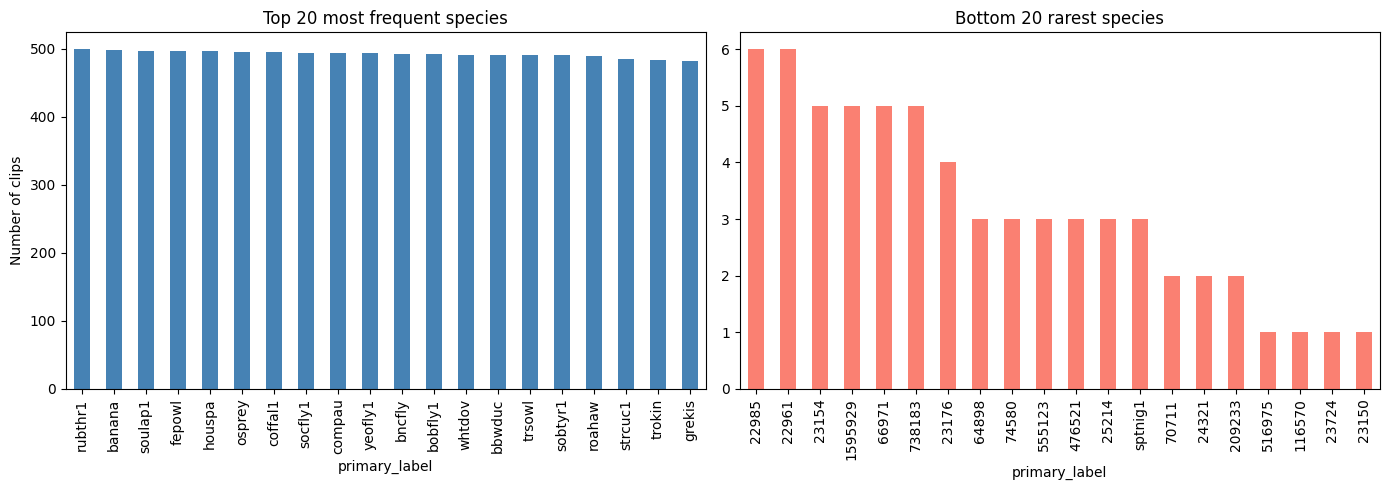

[1/7] Species distribution saved.
  Total species: 206, max clips: 499 (rubthr1), min: 1 (516975), median: 125
  Species with 1 clip: 4, with ≤5 clips: 18


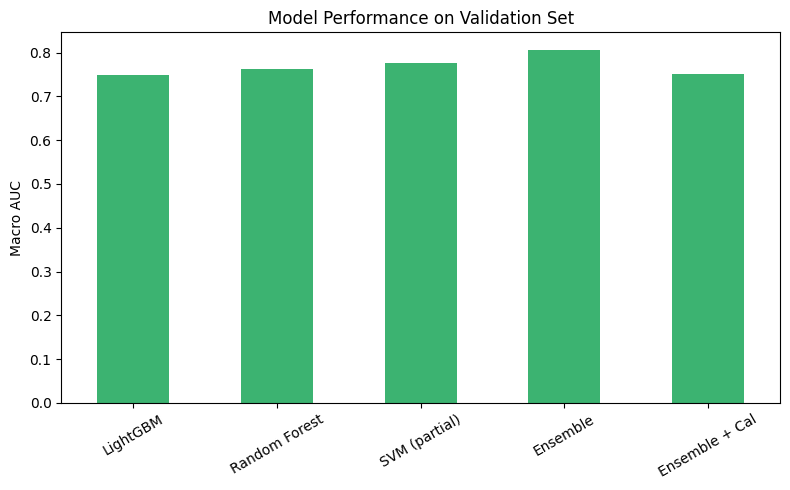

[2/7] Model comparison saved.
  LightGBM                 : 0.7486
  Random Forest            : 0.7636
  SVM (partial)            : 0.7758
  Ensemble                 : 0.8060
  Ensemble + Cal           : 0.7502


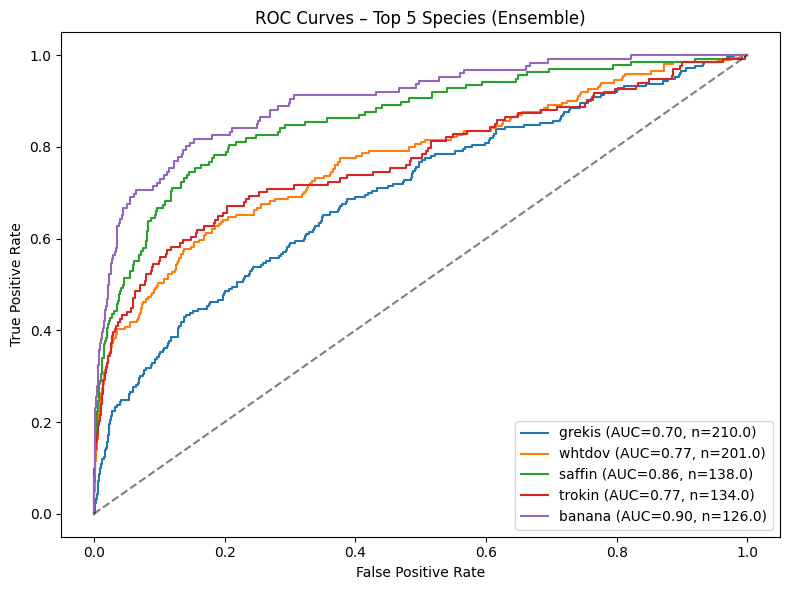

[3/7] ROC curves saved.


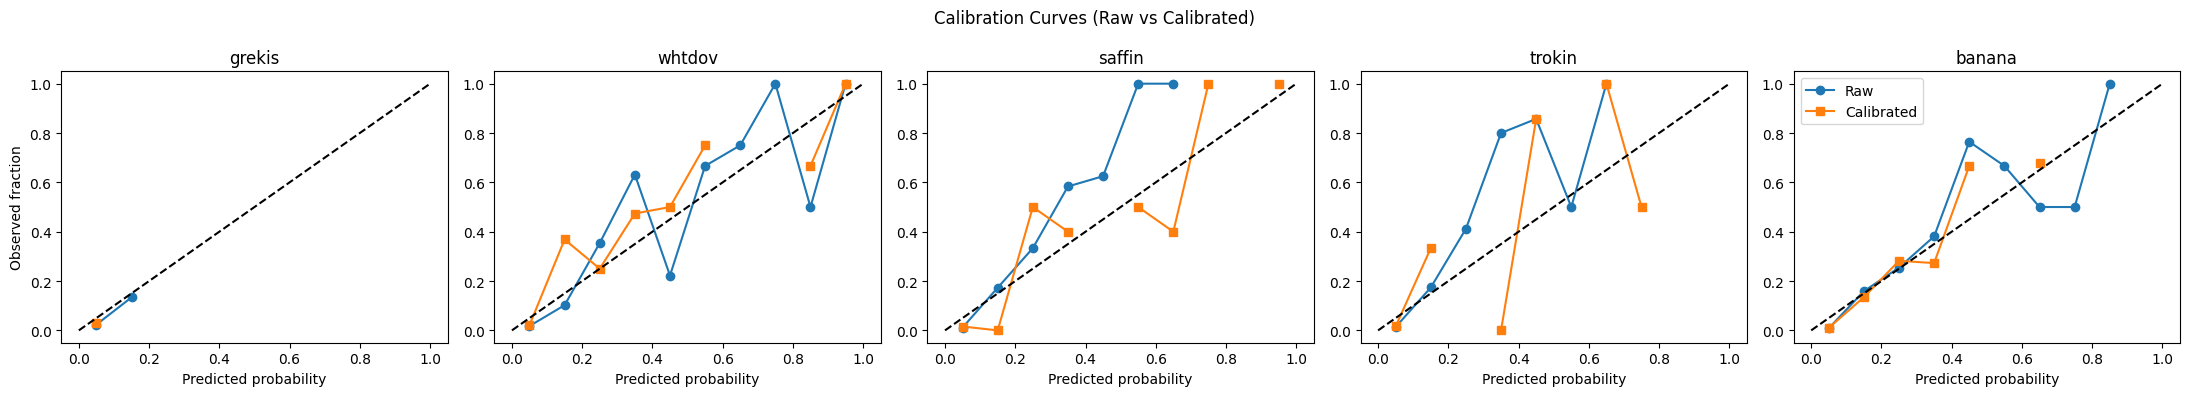

[4/7] Calibration curves saved.
  Isotonic: 102, Platt: 54, None: 78
  Macro AUC raw ensemble: 0.8060, calibrated: 0.7502


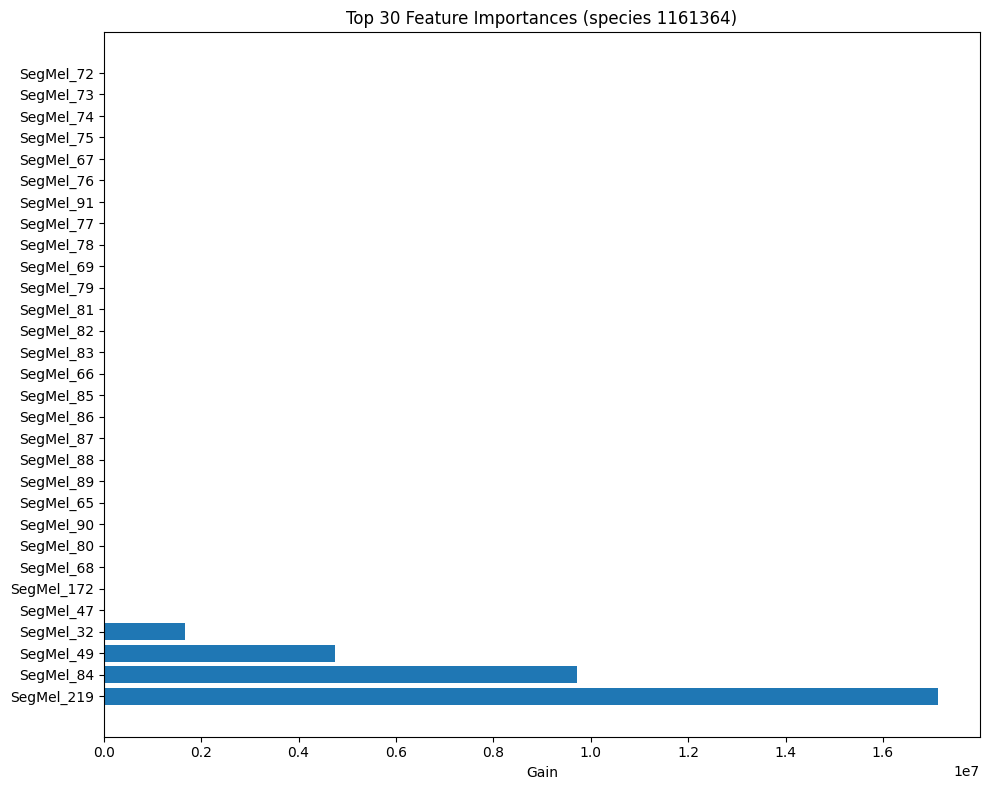

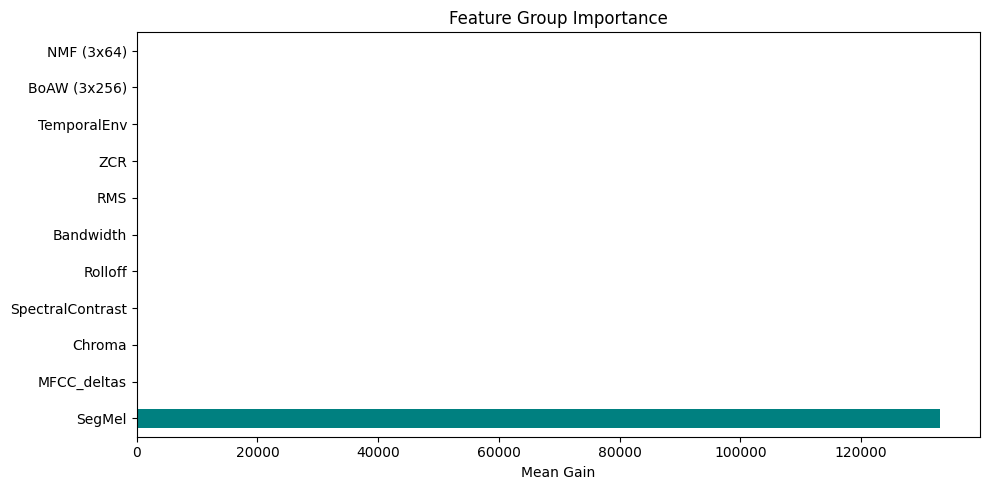

[5/7] Feature importance saved.
  Top 5 feature groups:
    SegMel                   : 133071.0182
    MFCC_deltas              : nan
    Chroma                   : nan
    SpectralContrast         : nan
    Rolloff                  : nan
  Top 5 individual features:
    SegMel_219                    : 17135312.70
    SegMel_84                     : 9721581.00
    SegMel_49                     : 4739052.00
    SegMel_32                     : 1667100.00
    SegMel_47                     : 2425.09

[6/7] Running ablation study (this may take a few minutes)...
  Ablation species: chvcon1 (train pos: 116.0, val pos: 26.0)
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[119]	valid_0's auc: 0.860929
  Baseline (all features): AUC = 0.8609
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[5]	valid_0's auc: 0.81615
    Without SegMel                   : AUC = 0.8161
Training until validation scores 

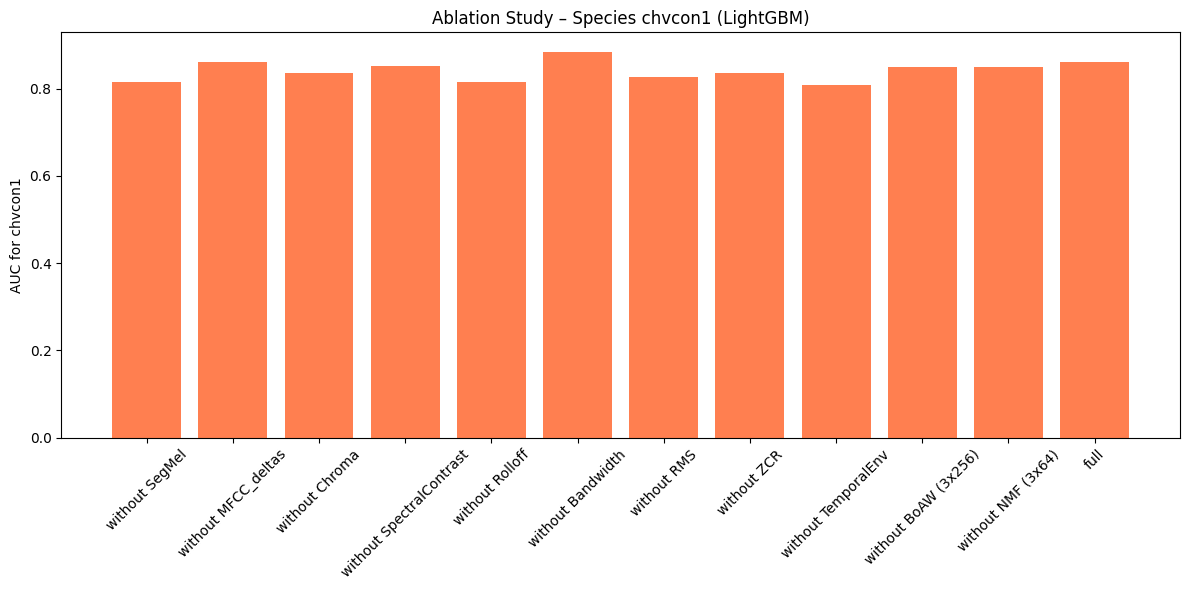

[6/7] Ablation study saved.

[7/7] Analysing hierarchical prior effect...
  Macro AUC without hierarchical prior : 0.8060
  Macro AUC with hierarchical prior    : 0.7312
  Difference (with - without)          : -0.0748


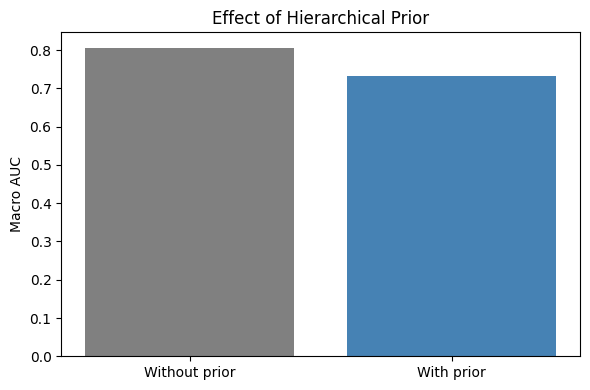

[7/7] Hierarchical prior analysis saved.

===== Analysis complete =====
Generated files:
  fig1_species_distribution.png
  fig2_model_comparison.png
  fig3_roc_curves.png
  fig4_calibration_curves.png
  fig5a_feature_importance_top30.png
  fig5b_feature_group_importance.png
  fig6_ablation_study.png
  fig7_hierarchical_prior.png
  ablation_results.csv, final_model_performance.csv


In [4]:
# =============================================================================
# FINAL COMPREHENSIVE ANALYSIS SCRIPT
# Generates all figures and data tables for the report.
# Uses: features_35549.npz, all *.pkl in saved_models/
# =============================================================================
import os, pickle, gc, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.cluster import KMeans
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from collections import Counter, OrderedDict

# ── Paths ──────────────────────────────────────────────────────────────────
DATA_DIR = './kaggle/input/competitions/birdclef-2026'
CACHE_FILE = './cache/features_35549.npz'
MODEL_DIR = './saved_models'

# ── Load metadata ──────────────────────────────────────────────────────────
sub = pd.read_csv(os.path.join(DATA_DIR, 'sample_submission.csv'))
SPECIES_LIST = sub.columns.tolist()[1:]
NUM_CLASSES = len(SPECIES_LIST)
train_df = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))

# ── Load feature cache ─────────────────────────────────────────────────────
data = np.load(CACHE_FILE)
X_raw = data['X']            # (35549, 2086)
y = data['y']                # (35549, 234)

# ── Load preprocessors ─────────────────────────────────────────────────────
with open(os.path.join(MODEL_DIR, 'scaler.pkl'), 'rb') as f: scaler = pickle.load(f)
with open(os.path.join(MODEL_DIR, 'pca.pkl'), 'rb') as f: pca = pickle.load(f)
with open(os.path.join(MODEL_DIR, 'selector.pkl'), 'rb') as f: selector = pickle.load(f)

# ── Preprocess all data ────────────────────────────────────────────────────
X_scaled = scaler.transform(X_raw)
X_scaled = np.nan_to_num(X_scaled)
X_pca = pca.transform(X_scaled)
X_proc = selector.transform(X_pca)   # final 250-dim features used by models

# ── Recreate the exact train/val split (same random_state=42) ──────────────
def make_split(df, X, y, test_size=0.2, random_state=42):
    counts = Counter(df['primary_label'])
    rare = {sp for sp, c in counts.items() if c == 1}
    rare_idx = df.index[df['primary_label'].isin(rare)].tolist()
    other_idx = df.index[~df['primary_label'].isin(rare)].tolist()
    other_lbl = df.loc[other_idx, 'primary_label']
    tr_o, val_idx = train_test_split(np.array(other_idx), test_size=test_size,
                                     stratify=other_lbl, random_state=random_state)
    train_idx = np.concatenate([tr_o, rare_idx])
    return train_idx, val_idx

train_idx, val_idx = make_split(train_df, X_proc, y)
X_tr, X_val = X_proc[train_idx], X_proc[val_idx]
y_tr, y_val = y[train_idx], y[val_idx]

# ── Load models ────────────────────────────────────────────────────────────
with open(os.path.join(MODEL_DIR, 'lgb_models.pkl'), 'rb') as f: lgb_models = pickle.load(f)
with open(os.path.join(MODEL_DIR, 'rf_models.pkl'), 'rb') as f: rf_models = pickle.load(f)
with open(os.path.join(MODEL_DIR, 'svm_models.pkl'), 'rb') as f: svm_models = pickle.load(f)
with open(os.path.join(MODEL_DIR, 'calibrators.pkl'), 'rb') as f: calibrators = pickle.load(f)
with open(os.path.join(MODEL_DIR, 'weights.pkl'), 'rb') as f: weights = pickle.load(f)
with open(os.path.join(MODEL_DIR, 'order_model.pkl'), 'rb') as f: order_model = pickle.load(f)
with open(os.path.join(MODEL_DIR, 'best_lgb_params.pkl'), 'rb') as f: best_lgb_params = pickle.load(f)

# ── Helper functions ───────────────────────────────────────────────────────
def macro_auc(y_true, y_pred):
    aucs = [roc_auc_score(y_true[:, i], y_pred[:, i])
            for i in range(y_true.shape[1]) if y_true[:, i].sum() > 0]
    return float(np.mean(aucs)) if aucs else 0.0

def apply_calibrators(preds, calibrators):
    out = preds.copy()
    for i, (kind, cal) in enumerate(calibrators):
        if kind == 'isotonic': out[:, i] = cal.transform(preds[:, i])
        elif kind == 'platt': out[:, i] = cal.predict_proba(preds[:, i].reshape(-1,1))[:,1]
    return out

# ── Compute validation predictions for all models ──────────────────────────
w_lgb, w_rf, w_svm = weights
svm_avail = np.array([svm_models[sp] is not None for sp in SPECIES_LIST])

lgb_val = np.zeros((len(X_val), NUM_CLASSES), dtype=np.float32)
rf_val  = np.zeros_like(lgb_val)
svm_val = np.zeros_like(lgb_val)

for i, sp in enumerate(SPECIES_LIST):
    if lgb_models[sp] is not None:
        lgb_val[:, i] = lgb_models[sp].predict(X_val)
    if rf_models[sp] is not None:
        rf_val[:, i] = rf_models[sp].predict_proba(X_val)[:, 1]
    if svm_models[sp] is not None:
        svm_val[:, i] = svm_models[sp].predict_proba(X_val)[:, 1]

# Ensemble without hierarchical prior
ensemble_raw = np.zeros_like(lgb_val)
for i in range(NUM_CLASSES):
    if svm_avail[i]:
        ensemble_raw[:, i] = w_lgb*lgb_val[:, i] + w_rf*rf_val[:, i] + w_svm*svm_val[:, i]
    else:
        denom = w_lgb + w_rf
        if denom > 0:
            ensemble_raw[:, i] = (w_lgb/denom)*lgb_val[:, i] + (w_rf/denom)*rf_val[:, i]

# Calibrated version of the ensemble (as used in final submission)
ensemble_cal = apply_calibrators(ensemble_raw, calibrators)

# ============================================================================
# FIGURE 1: Species distribution (Top 20 / Bottom 20)
# ============================================================================
counts = train_df['primary_label'].value_counts()
fig, axes = plt.subplots(1,2, figsize=(14,5))
counts.head(20).plot.bar(ax=axes[0], color='steelblue')
axes[0].set_title('Top 20 most frequent species'); axes[0].set_ylabel('Number of clips')
counts.tail(20).plot.bar(ax=axes[1], color='salmon')
axes[1].set_title('Bottom 20 rarest species')
plt.tight_layout(); plt.savefig('fig1_species_distribution.png', dpi=200); plt.show()
print("[1/7] Species distribution saved.")

# ── Print stats ──
print(f"  Total species: {counts.count()}, max clips: {counts.max()} ({counts.idxmax()}), "
      f"min: {counts.min()} ({counts.idxmin()}), median: {counts.median():.0f}")
print(f"  Species with 1 clip: {(counts==1).sum()}, with ≤5 clips: {(counts<=5).sum()}")

# ============================================================================
# FIGURE 2: Model comparison bar chart (macro AUC on validation)
# ============================================================================
metrics = {
    'LightGBM':       macro_auc(y_val, lgb_val),
    'Random Forest':  macro_auc(y_val, rf_val),
    'SVM (partial)':  macro_auc(y_val, svm_val),
    'Ensemble':       macro_auc(y_val, ensemble_raw),
    'Ensemble + Cal': macro_auc(y_val, ensemble_cal)
}
plt.figure(figsize=(8,5))
pd.Series(metrics).plot.bar(color='mediumseagreen')
plt.ylabel('Macro AUC'); plt.title('Model Performance on Validation Set')
plt.xticks(rotation=30); plt.tight_layout()
plt.savefig('fig2_model_comparison.png', dpi=200); plt.show()
print("[2/7] Model comparison saved.")
for k, v in metrics.items():
    print(f"  {k:<25s}: {v:.4f}")

# ============================================================================
# FIGURE 3: ROC curves for top 5 most frequent species (using Ensemble raw)
# ============================================================================
pos_counts_val = y_val.sum(axis=0)
top5_idx = np.argsort(pos_counts_val)[-5:][::-1]
plt.figure(figsize=(8,6))
for i in top5_idx:
    if pos_counts_val[i] == 0: continue
    fpr, tpr, _ = roc_curve(y_val[:, i], ensemble_raw[:, i])
    auc = roc_auc_score(y_val[:, i], ensemble_raw[:, i])
    plt.plot(fpr, tpr, label=f'{SPECIES_LIST[i]} (AUC={auc:.2f}, n={pos_counts_val[i]})')
plt.plot([0,1],[0,1],'k--', alpha=0.5)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves – Top 5 Species (Ensemble)')
plt.legend(); plt.tight_layout()
plt.savefig('fig3_roc_curves.png', dpi=200); plt.show()
print("[3/7] ROC curves saved.")

# ============================================================================
# FIGURE 4: Calibration curves (raw ensemble vs calibrated) for top 5 species
# ============================================================================
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, i in zip(axes, top5_idx):
    if pos_counts_val[i] == 0: continue
    bins = np.linspace(0, 1, 11)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    # raw
    bin_ids = np.digitize(ensemble_raw[:, i], bins) - 1
    bin_true = [y_val[:, i][bin_ids == j].mean() for j in range(len(bins)-1)]
    ax.plot(bin_centers, bin_true, 'o-', label='Raw')
    # calibrated
    bin_ids_c = np.digitize(ensemble_cal[:, i], bins) - 1
    bin_true_c = [y_val[:, i][bin_ids_c == j].mean() for j in range(len(bins)-1)]
    ax.plot(bin_centers, bin_true_c, 's-', label='Calibrated')
    ax.plot([0, 1], [0, 1], 'k--')
    ax.set_title(SPECIES_LIST[i])
    ax.set_xlabel('Predicted probability')
axes[0].set_ylabel('Observed fraction')          
fig.suptitle('Calibration Curves (Raw vs Calibrated)')
plt.legend()
plt.tight_layout()
plt.savefig('fig4_calibration_curves.png', dpi=200)
plt.show()
print("[4/7] Calibration curves saved.")

# ── Calibration stats ──
n_iso = sum(1 for kind,_ in calibrators if kind=='isotonic')
n_platt = sum(1 for kind,_ in calibrators if kind=='platt')
n_none = sum(1 for kind,_ in calibrators if kind=='none')
print(f"  Isotonic: {n_iso}, Platt: {n_platt}, None: {n_none}")
print(f"  Macro AUC raw ensemble: {metrics['Ensemble']:.4f}, calibrated: {metrics['Ensemble + Cal']:.4f}")

# ============================================================================
# FIGURE 5: Feature importance (single species + group mean importance)
# ============================================================================
# Feature group dimensions (must match your 2086 features)
FEATURE_GROUPS = OrderedDict([
    ('SegMel',         768),
    ('MFCC_deltas',    240),
    ('Chroma',          24),
    ('SpectralContrast',14),
    ('Rolloff',          4),
    ('Bandwidth',        4),
    ('RMS',              4),
    ('ZCR',              4),
    ('TemporalEnv',     64),
    ('BoAW (3x256)',   768),
    ('NMF (3x64)',     192)
])
TOTAL_DIM = sum(FEATURE_GROUPS.values())

# Select any available LightGBM model
rep_sp = next(sp for sp in SPECIES_LIST if lgb_models[sp] is not None)
model = lgb_models[rep_sp]
importance = model.feature_importance(importance_type='gain')

# Build feature names
feat_names = []
for g, d in FEATURE_GROUPS.items():
    for j in range(d):
        feat_names.append(f"{g}_{j}")

# Top 30 individual features
top30_idx = np.argsort(importance)[-30:][::-1]
plt.figure(figsize=(10,8))
plt.barh(np.array(feat_names)[top30_idx], importance[top30_idx])
plt.xlabel('Gain'); plt.title(f'Top 30 Feature Importances (species {rep_sp})')
plt.tight_layout()
plt.savefig('fig5a_feature_importance_top30.png', dpi=200); plt.show()

# Group mean importance
group_imp = {}
start = 0
for name, d in FEATURE_GROUPS.items():
    end = start + d
    group_imp[name] = importance[start:end].mean()
    start = end
group_series = pd.Series(group_imp).sort_values(ascending=False)
plt.figure(figsize=(10,5))
group_series.plot.barh(color='teal')
plt.xlabel('Mean Gain'); plt.title('Feature Group Importance')
plt.tight_layout()
plt.savefig('fig5b_feature_group_importance.png', dpi=200); plt.show()
print("[5/7] Feature importance saved.")

# ── Print top groups and top individual features ──
print("  Top 5 feature groups:")
for g, v in group_series.head(5).items():
    print(f"    {g:25s}: {v:.4f}")
print("  Top 5 individual features:")
for idx in top30_idx[:5]:
    print(f"    {feat_names[idx]:30s}: {importance[idx]:.2f}")

# ============================================================================
# FIGURE 6: Ablation study on a representative species
# ============================================================================
print("\n[6/7] Running ablation study (this may take a few minutes)...")

# Pick a species with a moderate number of training positives
pos_counts = y_tr.sum(axis=0)
median_pos = np.median(pos_counts[pos_counts > 0])
candidate_idx = np.argmin(np.abs(pos_counts - median_pos))
rep_sp_abl = SPECIES_LIST[candidate_idx]
y_tr_abl = y_tr[:, candidate_idx]
y_val_abl = y_val[:, candidate_idx]
# fallback if not enough positives
if y_tr_abl.sum() == 0 or y_val_abl.sum() == 0:
    for i, sp in enumerate(SPECIES_LIST):
        if y_tr[:, i].sum() > 10 and y_val[:, i].sum() > 5:
            rep_sp_abl = sp
            y_tr_abl = y_tr[:, i]
            y_val_abl = y_val[:, i]
            break
print(f"  Ablation species: {rep_sp_abl} (train pos: {y_tr_abl.sum()}, val pos: {y_val_abl.sum()})")

# Base LightGBM parameters (same as trained)
base_params = {
    'objective': 'binary', 'metric': 'auc', 'boosting_type': 'gbdt',
    'verbose': -1, 'n_jobs': -1, 'seed': 42, **best_lgb_params
}
base_params.setdefault('num_leaves', 63)
base_params.setdefault('learning_rate', 0.05)
base_params.setdefault('feature_fraction', 0.8)
base_params.setdefault('bagging_fraction', 0.8)
base_params.setdefault('bagging_freq', 5)
base_params.setdefault('min_child_samples', 5)

def train_and_eval_auc(X_tr_raw, X_val_raw, y_tr_s, y_val_s, params):
    """Train a LightGBM on raw feature subset and return val AUC."""
    sc = StandardScaler()
    X_tr_scaled = sc.fit_transform(X_tr_raw)
    X_tr_scaled = np.nan_to_num(X_tr_scaled)
    pca_sub = PCA(n_components=min(350, X_tr_scaled.shape[1]), random_state=42)
    X_tr_pca = pca_sub.fit_transform(X_tr_scaled)
    X_val_scaled = sc.transform(X_val_raw)
    X_val_scaled = np.nan_to_num(X_val_scaled)
    X_val_pca = pca_sub.transform(X_val_scaled)
    sel = SelectKBest(f_classif, k=min(250, X_tr_pca.shape[1]))
    X_tr_proc = sel.fit_transform(X_tr_pca, y_tr_s)
    X_val_proc = sel.transform(X_val_pca)

    pos = y_tr_s.sum(); neg = len(y_tr_s) - pos
    p = params.copy()
    p['scale_pos_weight'] = neg / pos

    model = lgb.train(p, lgb.Dataset(X_tr_proc, label=y_tr_s),
                      valid_sets=[lgb.Dataset(X_val_proc, label=y_val_s)],
                      num_boost_round=300,
                      callbacks=[lgb.early_stopping(30), lgb.log_evaluation(0)])
    preds = model.predict(X_val_proc)
    return roc_auc_score(y_val_s, preds)

# Full features baseline
X_tr_full = X_raw[train_idx]
X_val_full = X_raw[val_idx]
baseline_auc = train_and_eval_auc(X_tr_full, X_val_full, y_tr_abl, y_val_abl, base_params)
print(f"  Baseline (all features): AUC = {baseline_auc:.4f}")

# Ablation results
ablation_results = {}
for group_name, (s, e) in group_slices.items():
    mask = np.ones(TOTAL_DIM, dtype=bool)
    mask[s:e] = False
    X_tr_sub = X_tr_full[:, mask]
    X_val_sub = X_val_full[:, mask]
    auc = train_and_eval_auc(X_tr_sub, X_val_sub, y_tr_abl, y_val_abl, base_params)
    ablation_results[f'without {group_name}'] = auc
    print(f"    Without {group_name:25s}: AUC = {auc:.4f}")

ablation_results['full'] = baseline_auc

# Plot
names = list(ablation_results.keys())
vals = list(ablation_results.values())
plt.figure(figsize=(12,6))
plt.bar(names, vals, color='coral')
plt.xticks(rotation=45)
plt.ylabel(f'AUC for {rep_sp_abl}')
plt.title(f'Ablation Study – Species {rep_sp_abl} (LightGBM)')
plt.tight_layout()
plt.savefig('fig6_ablation_study.png', dpi=200); plt.show()
ablation_df = pd.DataFrame({'Configuration': names, 'AUC': vals})
ablation_df.to_csv('ablation_results.csv', index=False)
print("[6/7] Ablation study saved.")

# ============================================================================
# FIGURE 7: Effect of hierarchical prior
# ============================================================================
print("\n[7/7] Analysing hierarchical prior effect...")

# Rebuild pseudo‑order mapping from training features (same as training)
def rebuild_pseudo_order_map(X, y, species_list, n_pseudo=12, random_state=42):
    sp_means = {}
    for i, sp in enumerate(species_list):
        mask = y[:, i] == 1
        if mask.sum() >= 2:
            sp_means[sp] = X[mask].mean(axis=0)
    sp_list = list(sp_means.keys())
    if len(sp_list) < n_pseudo:
        n_pseudo = max(2, len(sp_list)//2)
    centroids = np.array([sp_means[sp] for sp in sp_list])
    km = KMeans(n_clusters=n_pseudo, random_state=random_state, n_init=5)
    pseudo_labels = km.fit_predict(centroids)
    sp2pseudo = {sp: int(pseudo_labels[i]) for i, sp in enumerate(sp_list)}
    for sp in species_list:
        if sp not in sp2pseudo:
            sp2pseudo[sp] = 0
    return sp2pseudo, n_pseudo

sp2pseudo, n_pseudo_orders = rebuild_pseudo_order_map(X_tr, y_tr, SPECIES_LIST,
                                                       n_pseudo=12, random_state=42)
sp_order_map = np.array([sp2pseudo.get(sp, 0) for sp in SPECIES_LIST], dtype=np.int32)

def apply_hierarchical_prior(species_preds, order_model, X, sp_order_map, n_orders, alpha=0.15):
    if order_model == 'uniform':
        return species_preds.copy()
    order_probs_remapped = order_model.predict(X)
    N = species_preds.shape[0] if species_preds.ndim == 2 else 1
    inv = order_model._order_remap_inverse
    order_probs_full = np.zeros((N, n_orders), dtype=np.float32)
    for cont, orig in inv.items():
        order_probs_full[:, orig] = order_probs_remapped[:, cont]
    adjusted = species_preds.copy() if species_preds.ndim == 2 else species_preds.reshape(1, -1).copy()
    for sp_idx in range(NUM_CLASSES):
        ord_idx = sp_order_map[sp_idx]
        prior = order_probs_full[:, ord_idx]
        adjusted[:, sp_idx] = (1 - alpha) * adjusted[:, sp_idx] + alpha * prior
    return adjusted if species_preds.ndim == 2 else adjusted.flatten()

ensemble_with_prior = apply_hierarchical_prior(
    ensemble_raw.copy(), order_model, X_val, sp_order_map, n_pseudo_orders, alpha=0.15
)
auc_no_prior = macro_auc(y_val, ensemble_raw)
auc_with_prior = macro_auc(y_val, ensemble_with_prior)

print(f"  Macro AUC without hierarchical prior : {auc_no_prior:.4f}")
print(f"  Macro AUC with hierarchical prior    : {auc_with_prior:.4f}")
print(f"  Difference (with - without)          : {auc_with_prior - auc_no_prior:.4f}")

# Plot a simple bar comparison
plt.figure(figsize=(6,4))
plt.bar(['Without prior', 'With prior'], [auc_no_prior, auc_with_prior], color=['gray','steelblue'])
plt.ylabel('Macro AUC')
plt.title('Effect of Hierarchical Prior')
plt.tight_layout()
plt.savefig('fig7_hierarchical_prior.png', dpi=200); plt.show()
print("[7/7] Hierarchical prior analysis saved.")

# ============================================================================
# FINAL SUMMARY TABLE (saved as CSV for easy inclusion in LaTeX)
# ============================================================================
summary_df = pd.DataFrame({
    'Model': ['LightGBM', 'Random Forest', 'SVM (partial)', 'Ensemble (raw)', 'Ensemble + Cal'],
    'Macro_AUC': [metrics['LightGBM'], metrics['Random Forest'], metrics['SVM (partial)'],
                  metrics['Ensemble'], metrics['Ensemble + Cal']]
})
summary_df.to_csv('final_model_performance.csv', index=False)

print("\n===== Analysis complete =====")
print("Generated files:")
print("  fig1_species_distribution.png")
print("  fig2_model_comparison.png")
print("  fig3_roc_curves.png")
print("  fig4_calibration_curves.png")
print("  fig5a_feature_importance_top30.png")
print("  fig5b_feature_group_importance.png")
print("  fig6_ablation_study.png")
print("  fig7_hierarchical_prior.png")
print("  ablation_results.csv, final_model_performance.csv")